In [24]:
import numpy as np
import pickle
from matplotlib import pyplot as plt

from qiskit import transpile
from qiskit_ibm_runtime import QiskitRuntimeService


from qiskit.circuit import Parameter, ParameterVector

from hubo_qaoa.utils.parameterise_circuit import parameterise_circuit
from hubo_qaoa.utils.lr_qaoa import get_LR_qaoa_circuit, get_hardware_LR_qaoa_circuit



In [25]:
filename_to_copy_numbers = {
    'test_N4_W6': [2,2,1,1],
    'test_N9_W6': [1,1,0,0,1,0,1,1,1], 
    'test_N10_W6': [1,1,0,0,1,0,1,1,0,1],
}

In [26]:
service = QiskitRuntimeService(name='us_instance')
backend = service.backend(name='ibm_boston')

In [27]:
data_file = '/lustre/scratch127/qpg/jc59/new_hubo_formulation/circuit_depths/results.couplingall.precompute.0.pkl'
with open(data_file, 'rb') as f:
    res = pickle.load(f)



In [94]:
data_file = '/lustre/scratch127/qpg/jc59/new_hubo_formulation/circuit_depths/results.all2all.new.pkl'
with open(data_file, 'rb') as f:
    res_new = pickle.load(f)

In [95]:
res_new.keys()

dict_keys(['test_N2_W2', 'trivial', 'test_N3_W4', 'test_N4_W5', 'test_N4_W6', 'test_N5_W6', 'test_N7_W2', 'test_N7_W3', 'test_N7_W4', 'test_N7_W5', 'test_N8_W2', 'test_N8_W3', 'test_N8_W4', 'test_N8_W5', 'test_N8_W6', 'test_N9_W6', 'test_N10_W6', 'test_N14_W7'])

In [29]:
data_file = '/lustre/scratch127/qpg/jc59/new_hubo_formulation/circuit_depths/results.couplingheavy-hex.precompute.60.pkl'
with open(data_file, 'rb') as f:
    res_hardware = pickle.load(f)

In [ ]:
files_to_plot = list(res.keys())
files_to_plot

In [30]:
delta_b, delta_g = 0.75, 0.30
p = 1

In [31]:
depths_abstract = []
counts_abstract = []
widths = []
# files_to_plot = [
#  'test_N2_W2',
#  'trivial',
#  'test_N3_W4',
#  'test_N4_W5',
#  'test_N4_W6',
#  ]
for filename in files_to_plot:
    try:
        cost_circuit = res[filename]['rzz']['circuit']
        num_qubits = cost_circuit.num_qubits
        phis = ParameterVector('ϕ', num_qubits)
        fixed_qc, circuit = get_LR_qaoa_circuit(p, delta_b, delta_g, num_qubits, cost_circuit, None, phis, True)
        
        widths.append(num_qubits)
        depths_abstract.append(fixed_qc.depth(lambda instr: len(instr.qubits) > 1))
        counts_abstract.append(sum([v for k, v in fixed_qc.count_ops().items() if k in ['rzz', 'cz', 'cx']]))
    except:
        print(f'No data: {filename}')
widths = np.array(widths)    
depths_abstract = np.array(depths_abstract)    
counts_abstract = np.array(counts_abstract)    


15:42:01 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 15
15:42:01 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 145
15:42:01 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 173
15:42:01 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 227
15:42:01 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 398
15:42:01 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 771
15:42:01 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 850
15:42:01 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 268
15:42:01 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 1127
15:42:02 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 300
15:42:02 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 554
15:42:02 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 613
15:42:02 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 896
15:42:02 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 1040


In [104]:
list(res_new.keys())

['test_N2_W2',
 'trivial',
 'test_N3_W4',
 'test_N4_W5',
 'test_N4_W6',
 'test_N5_W6',
 'test_N7_W2',
 'test_N7_W3',
 'test_N7_W4',
 'test_N7_W5',
 'test_N8_W2',
 'test_N8_W3',
 'test_N8_W4',
 'test_N8_W5',
 'test_N8_W6',
 'test_N9_W6',
 'test_N10_W6',
 'test_N14_W7']

In [105]:
depths_new = []
counts_new = []
widths_new = []
files_to_plot = [
'test_N2_W2',
 'trivial',
 'test_N3_W4',
 'test_N4_W5',
 'test_N4_W6',
 'test_N5_W6',
 'test_N7_W2',
 'test_N7_W3',
 'test_N7_W4',
 'test_N7_W5',
 'test_N8_W2',
 'test_N8_W3',
 'test_N8_W4',
 'test_N8_W5',
 'test_N8_W6',
 ]
# files_to_plot = res_new.keys()
for filename in files_to_plot:
    try:
        cost_circuit = res_new[filename]['rz']['circuit']
        num_qubits = cost_circuit.num_qubits
        phis = ParameterVector('ϕ', num_qubits)
        fixed_qc, circuit = get_LR_qaoa_circuit(p, delta_b, delta_g, num_qubits, cost_circuit, None, phis, True)
        
        widths_new.append(num_qubits)
        depths_new.append(fixed_qc.depth(lambda instr: len(instr.qubits) > 1))
        counts_new.append(sum([v for k, v in fixed_qc.count_ops().items() if k in ['rzz', 'cz', 'cx']]))
    except Exception as e:
        print(e)
        print(f'No data: {filename}')
widths_new = np.array(widths_new)    
depths_new = np.array(depths_new)    
counts_new = np.array(counts_new)    


16:06:15 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 15
16:06:15 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 97
16:06:15 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 184
16:06:15 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 222
16:06:15 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 245
16:06:15 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 1552
16:06:15 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 283
16:06:15 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 568
16:06:15 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 780
16:06:15 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 1288
16:06:15 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 286
16:06:15 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 533
16:06:15 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 513
16:06:15 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 792
16:06:16 - hubo_qaoa

In [ ]:
widths_hardware = []
depths_hardware = []
counts_hardware = []
for filename in files_to_plot:
    cost_circuit = res_hardware[filename]['rzz']['circuit']
    try:
        num_qubits = res[filename]['rzz']['circuit'].num_qubits
    except:
        from hubo_qaoa.utils.gfa_utils import gfa_file_to_graph
        filepath = f'/nfs/users/nfs_j/jc59/quantumwork/pangenome/data/{filename}.gfa'
        _, n, _, T = gfa_file_to_graph(filepath, filename_to_copy_numbers[filename])
        print(filename, n, T)
        num_qubits: int = n*T
        
    phis = ParameterVector('ϕ', num_qubits)
    layout = res_hardware[filename]['rzz']['layout']
    try:
        fixed_qc, _, _ = get_hardware_LR_qaoa_circuit(p, delta_b, delta_g, num_qubits, cost_circuit, layout, backend, None, phis)    
        widths_hardware.append(num_qubits)
        depths_hardware.append(fixed_qc.depth(lambda instr: len(instr.qubits) > 1))
        counts_hardware.append(sum([v for k, v in fixed_qc.count_ops().items() if k in ['rzz', 'cz', 'cx']]))
    except Exception as e:
        print(e)
widths_hardware = np.array(widths_hardware)    
depths_hardware = np.array(depths_hardware)    
counts_hardware = np.array(counts_hardware)     

In [ ]:
indices = np.argsort(widths)
print('filename qubits depths count')
for index in indices:
    print(np.array(files_to_plot)[index], widths[index], depths_abstract[index], counts_abstract[index])

In [ ]:
indices = np.argsort(widths_hardware)
print('filename qubits depths count')
for index in indices:
    print(files_to_plot[index], widths_hardware[index], depths_hardware[index], counts_hardware[index])

In [ ]:
"""
(no precompute)
filename qubits depths count
test_N2_W2 4 23 28
test_N7_W2 8 1398 2015
test_N8_W2 8 1251 1864
trivial 9 305 533
test_N7_W3 12 2794 4697
test_N3_W4 12 299 700
test_N8_W3 12 2444 4057
test_N4_W5 15 931 1691
test_N8_W4 16 2854 5265
test_N7_W4 16 4570 8663
test_N4_W6 18 848 1695
test_N7_W5 20 5575 12571
test_N8_W5 20 3282 7758
"""

In [ ]:
files_to_fit = [
    "test_N8_W2" ,
    "test_N8_W3" ,
    "test_N8_W4" ,
    "test_N8_W5" ,
    "test_N8_W6" ,
]
indices_to_fit = [files_to_plot.index(f) for f in files_to_fit]

In [ ]:
grid = np.linspace(
    min(widths[indices_to_fit][0], widths_hardware[indices_to_fit][0]),
    max(widths[indices_to_fit][-1], widths_hardware[indices_to_fit][-1]), 
    100
)

p_depth = np.polynomial.Polynomial.fit(widths[indices_to_fit], depths_abstract[indices_to_fit], 1, full=True)
p_depth_hardware = np.polynomial.Polynomial.fit(widths_hardware[indices_to_fit], depths_hardware[indices_to_fit], 1, full=True)
p_count = np.polynomial.Polynomial.fit(widths[indices_to_fit], counts_abstract[indices_to_fit], 1)
p_count_hardware = np.polynomial.Polynomial.fit(widths_hardware[indices_to_fit], counts_hardware[indices_to_fit], 1)
print(p_depth)
print(p_depth_hardware)
p_depth = p_depth[0]
p_depth_hardware = p_depth_hardware[0]

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import MultipleLocator, MaxNLocator

# --- helper for rounding y-axis nicely (keep your existing function if preferred) ---
def nice_upper_limit(data, n_ticks=6):
    max_val = np.max(data)
    raw_step = max_val / (n_ticks - 1)
    magnitude = 10 ** np.floor(np.log10(raw_step))
    residual = raw_step / magnitude
    if residual < 1:
        nice_step = 1 * magnitude
    elif residual < 2:
        nice_step = 2 * magnitude
    elif residual < 2.5:
        nice_step = 2.5 * magnitude
    elif residual < 5:
        nice_step = 5 * magnitude
    else:
        nice_step = 10 * magnitude
    upper = nice_step * (n_ticks - 1)
    return upper, nice_step

# ---- compact publication style for small panels ----
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 7,
    "axes.titlesize": 8,
    "axes.labelsize": 7,
    "legend.fontsize": 6,
    "figure.dpi": 300,
    "lines.linewidth": 1.2,
})

# small figure sized so two can sit side-by-side on A4 with 1 in margins
fig, ax1 = plt.subplots(figsize=(3.1, 2.4))

# colours & markers
depth_color = "#FD8153"
count_color = '#5366E0'
abstract_marker = 'X'
hardware_marker = 'o'

# reduced marker and line sizes for compactness
marker_size = 4        # smaller marker
edge_width = 0.3
linewidth_fit = 1.0
alpha_scatter = 0.95

# --- Depth (left axis) ---
ax1.scatter(widths, depths_abstract,
            color=depth_color, marker=abstract_marker,
            s=marker_size**2, linewidths=edge_width, alpha=alpha_scatter)
ax1.scatter(widths_hardware, depths_hardware,
            color=depth_color, marker=hardware_marker,
            s=marker_size**2, linewidths=edge_width, alpha=alpha_scatter)
ax1.plot(grid, p_depth(grid), linestyle='--', color=depth_color,
         linewidth=linewidth_fit)
ax1.plot(grid, p_depth_hardware(grid), linestyle='-', color=depth_color,
         linewidth=linewidth_fit)

ax1.set_xlabel('Number of qubits', fontsize=7)
ax1.set_ylabel('2-qubit gate depth', color=depth_color, fontsize=7)
ax1.tick_params(axis='y', labelcolor=depth_color, labelsize=7)
ax1.xaxis.set_major_locator(MaxNLocator(5))  # fewer, neat x-ticks
ax1.tick_params(axis='x', labelsize=7)

# --- Count (right axis) ---
ax2 = ax1.twinx()
ax2.scatter(widths, counts_abstract,
            color=count_color, marker=abstract_marker,
            s=marker_size**2, linewidths=edge_width, alpha=alpha_scatter)
ax2.scatter(widths_hardware, counts_hardware,
            color=count_color, marker=hardware_marker,
            s=marker_size**2, linewidths=edge_width, alpha=alpha_scatter)
ax2.plot(grid, p_count(grid), linestyle='--', color=count_color,
         linewidth=linewidth_fit)
ax2.plot(grid, p_count_hardware(grid), linestyle='-', color=count_color,
         linewidth=linewidth_fit)

ax2.set_ylabel('2-qubit gate count', color=count_color, fontsize=7)
ax2.tick_params(axis='y', labelcolor=count_color, labelsize=7)

# ---- nice rounded axes (same number of horizontal gridlines) ----
n_ticks = 8
depth_data = np.concatenate([depths_abstract, depths_hardware])
depth_upper, depth_step = nice_upper_limit(depth_data, n_ticks)
ax1.set_ylim(0, depth_upper)
ax1.yaxis.set_major_locator(MultipleLocator(depth_step))

count_data = np.concatenate([counts_abstract, counts_hardware])
count_upper, count_step = nice_upper_limit(count_data, n_ticks)
ax2.set_ylim(0, count_upper)
ax2.yaxis.set_major_locator(MultipleLocator(count_step))

# only draw gridlines from left axis for aligned horizontal guides
ax1.grid(True, axis='y', linestyle=':', linewidth=0.5, alpha=0.6)
ax2.grid(False)

# ---- compact combined legend (use 2 columns to conserve vertical space) ----
legend_elements = [
    Line2D([0], [0], color=depth_color, marker=abstract_marker, linestyle='--',
           markersize=4, linewidth=1.0, label='Abstract (depth)'),
    Line2D([0], [0], color=depth_color, marker=hardware_marker, linestyle='-',
           markersize=4, linewidth=1.0, label='Hardware (depth)'),
    Line2D([0], [0], color=count_color, marker=abstract_marker, linestyle='--',
           markersize=4, linewidth=1.0, label='Abstract (count)'),
    Line2D([0], [0], color=count_color, marker=hardware_marker, linestyle='-',
           markersize=4, linewidth=1.0, label='Hardware (count)'),
]
# place legend inside top-left without a frame, 2 columns
ax1.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(0.0, 1.0),
           frameon=False, ncol=2, handlelength=1.2, columnspacing=0.6,
           fontsize=6)

# Title and layout adjustments for the small panel
ax1.set_title('HUBO 2-qubit gate depth and count', fontsize=8, pad=6)
fig.subplots_adjust(left=0.11, right=0.94, top=0.88, bottom=0.13)

# Save at publication resolution (vector PDF + PNG)
fig.savefig('../../../out/hubo_2qubit_depth_count_small.png', bbox_inches='tight', dpi=300)

plt.show()

In [106]:
files_to_fit_0 = [
    "test_N8_W2" ,
    "test_N8_W3" ,
    "test_N8_W4" ,
    "test_N7_W5" ,
    "test_N5_W6" ,
]
indices_to_fit_0 = [files_to_plot.index(f) for f in files_to_fit_0]

files_to_fit_1 = [
    "test_N2_W2",
    "trivial",
    "test_N3_W4",
    "test_N4_W5",
    "test_N4_W6",
]
indices_to_fit_1 = [files_to_plot.index(f) for f in files_to_fit_1]


In [107]:
indices_to_fit_0, indices_to_fit_1

([10, 11, 12, 9, 5], [0, 1, 2, 3, 4])

In [108]:
widths_new, files_to_plot

(array([ 4,  9, 12, 15, 18, 24,  8, 12, 16, 20,  8, 12, 16, 20, 24]),
 ['test_N2_W2',
  'trivial',
  'test_N3_W4',
  'test_N4_W5',
  'test_N4_W6',
  'test_N5_W6',
  'test_N7_W2',
  'test_N7_W3',
  'test_N7_W4',
  'test_N7_W5',
  'test_N8_W2',
  'test_N8_W3',
  'test_N8_W4',
  'test_N8_W5',
  'test_N8_W6'])

In [109]:
grid_0 = np.linspace(
    widths_new[indices_to_fit_0][0],
    widths_new[indices_to_fit_0][-1], 
    100
)
grid_1 = np.linspace(
    min(widths_new[indices_to_fit_1]),
    max(widths_new[indices_to_fit_1]), 
    100
)
grid = np.linspace(
    max(min(widths_new[indices_to_fit_0]), min(widths_new[indices_to_fit_1])),
    64, 
    100
)


p_count_0 = np.polynomial.Polynomial.fit(widths_new[indices_to_fit_0], counts_new[indices_to_fit_0], 1)
p_count_1 = np.polynomial.Polynomial.fit(widths_new[indices_to_fit_1], counts_new[indices_to_fit_1], 1)


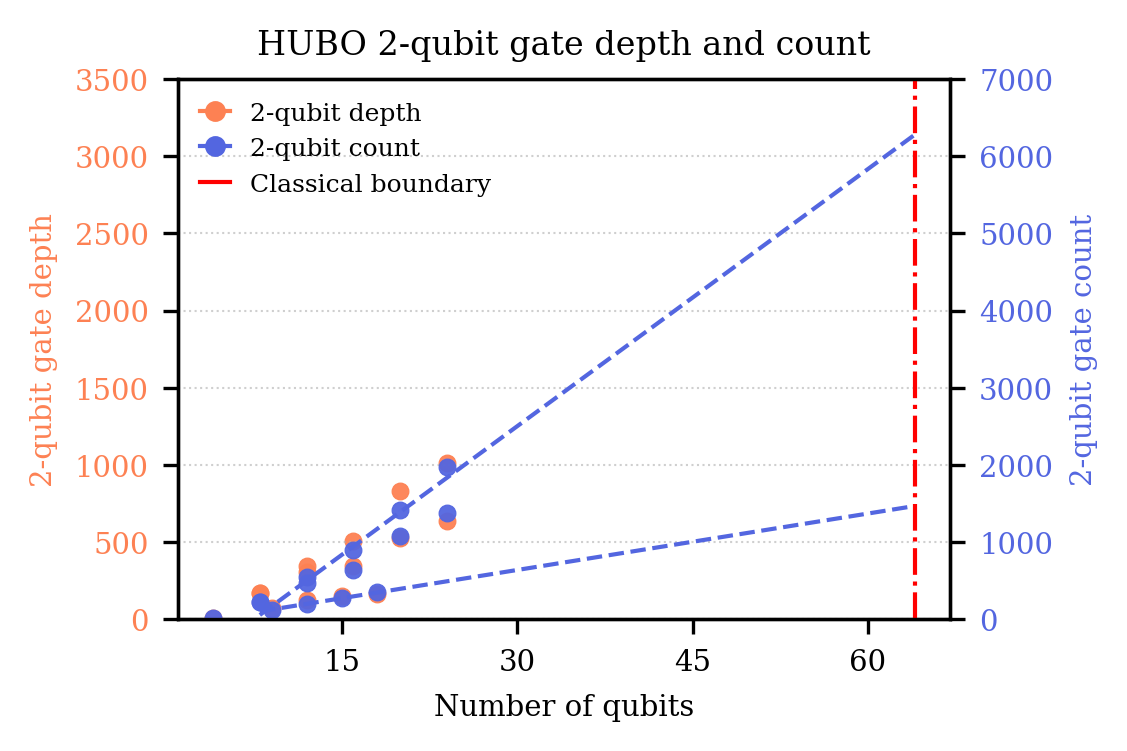

In [113]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import MultipleLocator, MaxNLocator

# --- helper for rounding y-axis nicely (keep your existing function if preferred) ---
def nice_upper_limit(data, n_ticks=6):
    max_val = np.max(data)
    raw_step = max_val / (n_ticks - 1)
    magnitude = 10 ** np.floor(np.log10(raw_step))
    residual = raw_step / magnitude
    if residual < 1:
        nice_step = 1 * magnitude
    elif residual < 2:
        nice_step = 2 * magnitude
    elif residual < 2.5:
        nice_step = 2.5 * magnitude
    elif residual < 5:
        nice_step = 5 * magnitude
    else:
        nice_step = 10 * magnitude
    upper = nice_step * (n_ticks - 1)
    return upper, nice_step

# ---- compact publication style for small panels ----
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 7,
    "axes.titlesize": 8,
    "axes.labelsize": 7,
    "legend.fontsize": 6,
    "figure.dpi": 300,
    "lines.linewidth": 1.2,
})

# small figure sized so two can sit side-by-side on A4 with 1 in margins
fig, ax1 = plt.subplots(figsize=(3.1, 2.4))

# colours & markers
depth_color = "#FD8153"
count_color = '#5366E0'
abstract_marker = 'X'
hardware_marker = 'o'

# reduced marker and line sizes for compactness
marker_size = 4        # smaller marker
edge_width = 0.3
linewidth_fit = 1.0
alpha_scatter = 0.95

# --- Depth (left axis) ---
# ax1.scatter(widths, depths_abstract,
#             color=depth_color, marker=abstract_marker,
#             s=marker_size**2, linewidths=edge_width, alpha=alpha_scatter)
ax1.scatter(widths_new, depths_new,
            color=depth_color, marker=hardware_marker,
            s=marker_size**2, linewidths=edge_width, alpha=alpha_scatter)
# ax1.plot(grid, p_depth(grid), linestyle='--', color=depth_color,
#          linewidth=linewidth_fit)

ax1.set_xlabel('Number of qubits', fontsize=7)
ax1.set_ylabel('2-qubit gate depth', color=depth_color, fontsize=7)
ax1.tick_params(axis='y', labelcolor=depth_color, labelsize=7)
ax1.xaxis.set_major_locator(MaxNLocator(5))  # fewer, neat x-ticks
ax1.tick_params(axis='x', labelsize=7)

# --- Count (right axis) ---
ax2 = ax1.twinx()
# ax2.scatter(widths, counts_abstract,
#             color=count_color, marker=abstract_marker,
#             s=marker_size**2, linewidths=edge_width, alpha=alpha_scatter)
ax2.scatter(widths_new, counts_new,
            color=count_color, marker=hardware_marker,
            s=marker_size**2, linewidths=edge_width, alpha=alpha_scatter)
ax2.plot(grid, p_count_0(grid), linestyle='--', color=count_color,
         linewidth=linewidth_fit)
ax2.plot(grid, p_count_1(grid), linestyle='--', color=count_color,
         linewidth=linewidth_fit)

ax2.set_ylabel('2-qubit gate count', color=count_color, fontsize=7)
ax2.tick_params(axis='y', labelcolor=count_color, labelsize=7)

# ---- nice rounded axes (same number of horizontal gridlines) ----
n_ticks = 8
depth_data = np.concatenate([depths_new, [3000]])
depth_upper, depth_step = nice_upper_limit(depth_data, n_ticks)
ax1.set_ylim(0, depth_upper)
ax1.yaxis.set_major_locator(MultipleLocator(depth_step))

count_data = np.concatenate([counts_new, [5000]])
count_upper, count_step = nice_upper_limit(count_data, n_ticks)
ax2.set_ylim(0, count_upper)
ax2.yaxis.set_major_locator(MultipleLocator(count_step))
ax2.plot([64,64], [0, count_upper], linestyle='-.', color='red',
         linewidth=linewidth_fit)

# only draw gridlines from left axis for aligned horizontal guides
ax1.grid(True, axis='y', linestyle=':', linewidth=0.5, alpha=0.6)
ax2.grid(False)

# ---- compact combined legend (use 2 columns to conserve vertical space) ----
legend_elements = [
    # Line2D([0], [0], color=depth_color, marker=abstract_marker, linestyle='--',
    #        markersize=4, linewidth=1.0, label='Abstract (depth)'),
    Line2D([0], [0], color=depth_color, marker=hardware_marker, linestyle='-',
           markersize=4, linewidth=1.0, label='2-qubit depth'),
    # Line2D([0], [0], color=count_color, marker=abstract_marker, linestyle='--',
    #        markersize=4, linewidth=1.0, label='Abstract (count)'),
    Line2D([0], [0], color=count_color, marker=hardware_marker, linestyle='-',
           markersize=4, linewidth=1.0, label='2-qubit count'),
    Line2D([0], [0], color='red', linestyle='-',
        linewidth=1.0, label='Classical boundary'),
]
# place legend inside top-left without a frame, 2 columns
ax1.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(0.0, 1.0),
           frameon=False, ncol=1, handlelength=1.2, columnspacing=0.6,
           fontsize=6)

# Title and layout adjustments for the small panel
ax1.set_title('HUBO 2-qubit gate depth and count', fontsize=8, pad=6)
fig.subplots_adjust(left=0.11, right=0.94, top=0.88, bottom=0.13)

# Save at publication resolution (vector PDF + PNG)
fig.savefig('../../../out/hubo_2qubit_depth_count_all_to_all_new.png', bbox_inches='tight', dpi=300)

plt.show()

In [103]:
indices = np.argsort(widths_new)
print('filename qubits depths count')
for index in indices:
    print(np.array(list(res_new.keys()))[index], widths_new[index], depths_new[index], counts_new[index])

filename qubits depths count
test_N2_W2 4 9 11
test_N7_W2 8 167 225
test_N8_W2 8 167 227
trivial 9 71 117
test_N7_W3 12 347 551
test_N3_W4 12 123 193
test_N8_W3 12 308 464
test_N4_W5 15 152 268
test_N7_W4 16 508 893
test_N8_W4 16 344 640
test_N4_W6 18 166 353
test_N7_W5 20 830 1413
test_N8_W5 20 528 1077
test_N5_W6 24 1012 1976
test_N8_W6 24 635 1374
test_N9_W6 30 4623 8434
test_N10_W6 30 3743 7260
test_N14_W7 35 4600 9318


In [ ]:
filename = 'test_N4_W5'
cost_circuit = res_hardware[filename]['rzz']['circuit']

try:
    num_qubits = res[filename]['rzz']['circuit'].num_qubits
except:
    from hubo_qaoa.utils.gfa_utils import gfa_file_to_graph
    filepath = f'/nfs/users/nfs_j/jc59/quantumwork/pangenome/data/{filename}.gfa'
    _, n, _, T = gfa_file_to_graph(filepath, filename_to_copy_numbers[filename])
    print(filename, n, T)
    num_qubits: int = n*T
    
phis = ParameterVector('ϕ', num_qubits)
layout = res_hardware[filename]['rzz']['layout']

fixed_qc, circuit, layout_circuit = get_hardware_LR_qaoa_circuit(p, delta_b, delta_g, num_qubits, cost_circuit, layout, backend, None, phis)
    

In [ ]:
layout_circuit.count_ops(),fixed_qc.count_ops()

In [ ]:
cost_circuit = res[filename]['rzz']['circuit']
num_qubits = cost_circuit.num_qubits
phis = ParameterVector('ϕ', num_qubits)
abstract_fixed_qc, circuit = get_LR_qaoa_circuit(p, delta_b, delta_g, num_qubits, cost_circuit, None, phis, True)

In [ ]:
abstract_fixed_qc.count_ops()

In [ ]:
(442/(442+414+121))

In [ ]:
cost_circuit.count_ops()

In [ ]:
res_hardware[filename]['default']['circuit'].count_ops()

In [ ]:
layout_circuit.count_ops(), fixed_qc.count_ops(),qaoa_circuit.count_ops()

In [ ]:
circuit.count_ops()

In [ ]:
from qiskit import generate_preset_pass_manager
generic_pm = generate_preset_pass_manager(optimization_level=3, backend=backend, scheduling_method="alap")
t_qaoa_circuit = generic_pm.run(qaoa_circuit)

In [ ]:
t_qaoa_circuit.count_ops()

In [ ]:
t_qaoa_circuit.draw(fold=-1, idle_wires=False)